# WP5 — Architecture Comparison: CNN (ResNet-50) vs Transformer (ViT-Base/16)

> **Deep Learning: CNN, Transformers, architecture design (Cours 3-4)**

This notebook provides a rigorous side-by-side comparison of two backbone architectures
for Person Re-Identification on Market-1501:

| Property | ResNet-50 | ViT-Base/16 |
|---|---|---|
| Architecture family | CNN (Convolutional) | Transformer (Self-Attention) |
| Inductive bias | Local (sliding kernel) | Global (full attention) |
| Feature dimension | 2048 | 768 |
| Pretrained on | ImageNet-1K | ImageNet-1K |
| Re-ID head | BN-Neck + Linear | BN-Neck + Linear |

**Sections:**
1. Computational cost analysis (parameters, FLOPs, inference speed)
2. Re-ID metric comparison (Rank-1, Rank-5, mAP)
3. CMC curves
4. Qualitative comparison
5. Embedding space visualisation (t-SNE)
6. Conclusions

## 0. Setup

In [1]:
import os
import sys
import yaml
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader
from torchvision import transforms

In [2]:
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())
print(f"Working directory: {os.getcwd()}")

Working directory: /root/Person-Re-Identification


In [3]:
from src.dataloaders.market_dataset import MarketDataset
from src.models.resnet50 import ResNet50
from src.models.vit import ViTReID
from src.utils.evaluator import extract_features, evaluate, compute_distmat
from src.utils.visualizer import visualize_results
from src.utils.logging import load_checkpoint

In [4]:
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)['reid_project']

device = torch.device(config['general']['device'])
print(f"Device: {device}")

Device: cuda


## 1. Computational Cost Analysis

We compare three cost dimensions:
- **Parameter count** — model size / memory footprint
- **FLOPs** (Multiply-Accumulate operations) — theoretical compute cost
- **Inference latency** — wall-clock time per image

In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# Helper: count parameters
# ──────────────────────────────────────────────────────────────────────────────

def count_parameters(model):
    """Returns (trainable, total) parameter counts."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total


# ──────────────────────────────────────────────────────────────────────────────
# Helper: estimate FLOPs via a forward hook that counts multiply-accumulates
# ──────────────────────────────────────────────────────────────────────────────

def estimate_flops(model, input_size, device):
    """
    Estimates FLOPs for a forward pass by counting operations in
    Linear and Conv2d layers (which dominate compute).

    Returns:
        total_flops (int): Approximate multiply-accumulate operations.
    """
    flops = []
    hooks = []

    def conv_hook(module, inp, out):
        batch, out_c, out_h, out_w = out.shape
        kernel_ops = module.kernel_size[0] * module.kernel_size[1] * (module.in_channels // module.groups)
        flops.append(kernel_ops * out_c * out_h * out_w * batch)

    def linear_hook(module, inp, out):
        batch = inp[0].shape[0]
        flops.append(module.in_features * module.out_features * batch)

    def attn_hook(module, inp, out):
        # MultiheadAttention: Q*K^T + softmax*V ≈ 2 * seq_len^2 * embed_dim
        x = inp[0]  # (seq_len, batch, embed_dim) or (batch, seq_len, embed_dim)
        if x.dim() == 3:
            seq_len = x.shape[-2] if x.shape[0] != 1 else x.shape[1]
            batch = x.shape[0] if x.shape[-2] != x.shape[0] else 1
            embed_dim = module.embed_dim
            # QKV projections + attention + output projection
            flops.append(batch * (3 * seq_len * embed_dim * embed_dim +  # QKV
                                  2 * seq_len * seq_len * embed_dim +    # Attention
                                  seq_len * embed_dim * embed_dim))      # Output proj

    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d):
            hooks.append(module.register_forward_hook(conv_hook))
        elif isinstance(module, torch.nn.Linear):
            hooks.append(module.register_forward_hook(linear_hook))
        elif isinstance(module, torch.nn.MultiheadAttention):
            hooks.append(module.register_forward_hook(attn_hook))

    model.eval()
    dummy = torch.randn(1, 3, *input_size).to(device)
    with torch.no_grad():
        model(dummy)

    for h in hooks:
        h.remove()

    return sum(flops)


# ──────────────────────────────────────────────────────────────────────────────
# Helper: benchmark inference latency
# ──────────────────────────────────────────────────────────────────────────────

def benchmark_latency(model, input_size, device, n_warmup=10, n_runs=50):
    """
    Measures average inference time per image (ms).
    Includes warmup iterations to stabilise GPU/MPS state.
    """
    model.eval()
    dummy = torch.randn(1, 3, *input_size).to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(dummy)

    # Synchronise before timing
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()

    # Timed runs
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            elif device.type == 'mps':
                torch.mps.synchronize()
            times.append((time.perf_counter() - t0) * 1000)  # ms

    return np.mean(times), np.std(times)

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Instantiate both models (no trained weights needed for cost analysis)
# ──────────────────────────────────────────────────────────────────────────────

m_cfg = config['models']['resnet50']
v_cfg = config['models']['vit']

NUM_CLASSES = config['market1501']['num_classes']
RESNET_SIZE = tuple(config['market1501']['img_size'])  # (256, 128)
VIT_SIZE    = tuple(v_cfg['img_size'])                  # (224, 224)

resnet_model = ResNet50(
    num_classes=NUM_CLASSES,
    feature_dim=m_cfg['feature_dim'],
    last_stride=m_cfg['last_stride']
).to(device)

vit_model = ViTReID(
    num_classes=NUM_CLASSES,
    feature_dim=v_cfg['feature_dim']
).to(device)

print("Models instantiated for cost analysis.")

Models instantiated for cost analysis.


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# Compute all cost metrics
# ──────────────────────────────────────────────────────────────────────────────

cost_metrics = {}

for name, model, input_size in [
    ('ResNet-50',   resnet_model, RESNET_SIZE),
    ('ViT-Base/16', vit_model,    VIT_SIZE),
]:
    trainable, total = count_parameters(model)
    flops = estimate_flops(model, input_size, device)
    latency_mean, latency_std = benchmark_latency(model, input_size, device)

    cost_metrics[name] = {
        'total_params':    total,
        'trainable_params': trainable,
        'flops':           flops,
        'input_size':      input_size,
        'feature_dim':     2048 if 'ResNet' in name else 768,
        'latency_mean':    latency_mean,
        'latency_std':     latency_std,
    }

    print(f"\n{name}:")
    print(f"  Parameters : {total/1e6:.1f}M (trainable: {trainable/1e6:.1f}M)")
    print(f"  FLOPs      : {flops/1e9:.2f} GFLOPs")
    print(f"  Input size : {input_size}")
    print(f"  Feature dim: {cost_metrics[name]['feature_dim']}")
    print(f"  Latency    : {latency_mean:.1f} ± {latency_std:.1f} ms/image")


ResNet-50:
  Parameters : 25.1M (trainable: 25.0M)
  FLOPs      : 4.05 GFLOPs
  Input size : (256, 128)
  Feature dim: 2048
  Latency    : 13.0 ± 0.6 ms/image



ViT-Base/16:
  Parameters : 86.4M (trainable: 86.4M)
  FLOPs      : 6.46 GFLOPs
  Input size : (224, 224)
  Feature dim: 768
  Latency    : 10.7 ± 0.6 ms/image


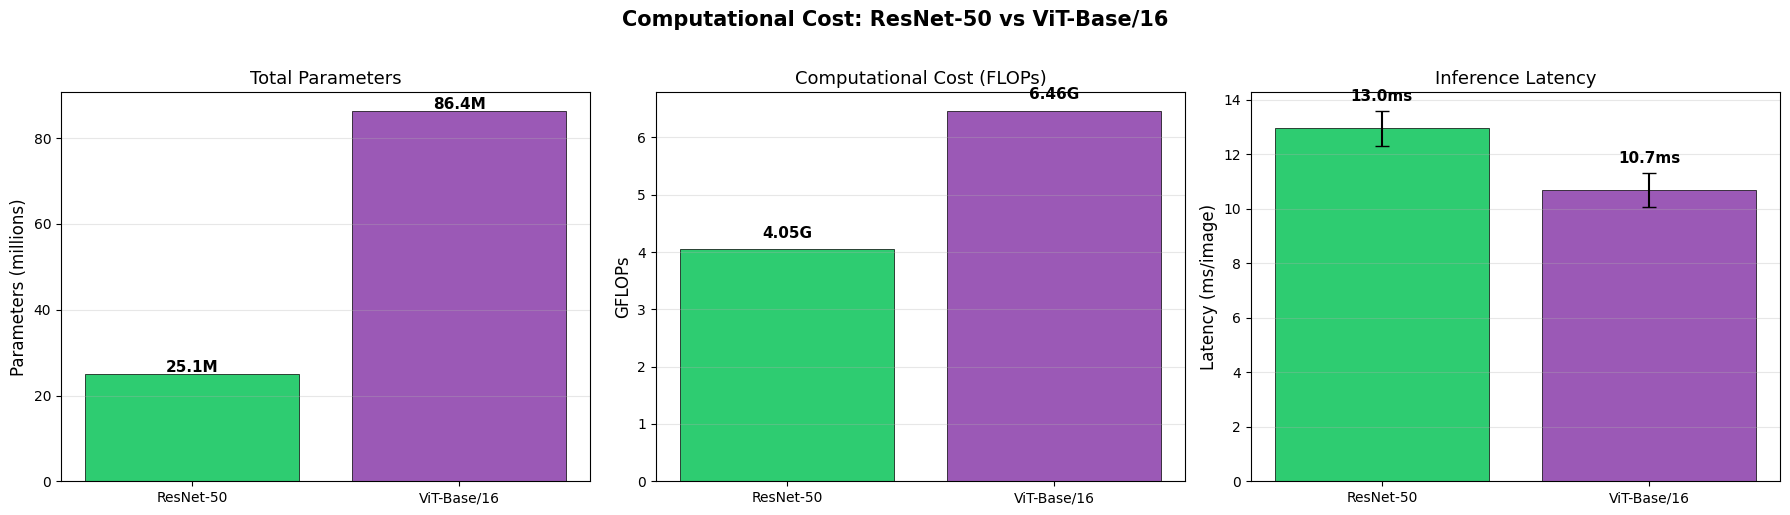

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# Figure 1: Computational cost comparison
# ──────────────────────────────────────────────────────────────────────────────

ARCH_NAMES  = ['ResNet-50', 'ViT-Base/16']
ARCH_COLORS = {'ResNet-50': '#2ecc71', 'ViT-Base/16': '#9b59b6'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Parameters
ax = axes[0]
vals = [cost_metrics[n]['total_params'] / 1e6 for n in ARCH_NAMES]
bars = ax.bar(ARCH_NAMES, vals, color=[ARCH_COLORS[n] for n in ARCH_NAMES],
              edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{v:.1f}M', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Parameters (millions)', fontsize=12)
ax.set_title('Total Parameters', fontsize=13)
ax.grid(axis='y', alpha=0.3)

# FLOPs
ax = axes[1]
vals = [cost_metrics[n]['flops'] / 1e9 for n in ARCH_NAMES]
bars = ax.bar(ARCH_NAMES, vals, color=[ARCH_COLORS[n] for n in ARCH_NAMES],
              edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{v:.2f}G', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('GFLOPs', fontsize=12)
ax.set_title('Computational Cost (FLOPs)', fontsize=13)
ax.grid(axis='y', alpha=0.3)

# Latency
ax = axes[2]
means = [cost_metrics[n]['latency_mean'] for n in ARCH_NAMES]
stds  = [cost_metrics[n]['latency_std'] for n in ARCH_NAMES]
bars  = ax.bar(ARCH_NAMES, means, yerr=stds, capsize=5,
              color=[ARCH_COLORS[n] for n in ARCH_NAMES],
              edgecolor='black', linewidth=0.5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{m:.1f}ms', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Latency (ms/image)', fontsize=12)
ax.set_title('Inference Latency', fontsize=13)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Computational Cost: ResNet-50 vs ViT-Base/16', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/architecture_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Print a clean summary table
print(f"{'Metric':<25} {'ResNet-50':>15} {'ViT-Base/16':>15} {'Ratio (ViT/RN)':>15}")
print('─' * 72)

r, v = cost_metrics['ResNet-50'], cost_metrics['ViT-Base/16']
rows = [
    ('Total Parameters',  f"{r['total_params']/1e6:.1f}M",    f"{v['total_params']/1e6:.1f}M",    f"{v['total_params']/r['total_params']:.2f}x"),
    ('Feature Dimension', f"{r['feature_dim']}",               f"{v['feature_dim']}",               f"{v['feature_dim']/r['feature_dim']:.2f}x"),
    ('FLOPs',             f"{r['flops']/1e9:.2f}G",           f"{v['flops']/1e9:.2f}G",           f"{v['flops']/r['flops']:.2f}x"),
    ('Input Resolution',  f"{r['input_size']}",               f"{v['input_size']}",               '—'),
    ('Latency (ms/img)',  f"{r['latency_mean']:.1f}±{r['latency_std']:.1f}",
                          f"{v['latency_mean']:.1f}±{v['latency_std']:.1f}",
                          f"{v['latency_mean']/r['latency_mean']:.2f}x"),
]
for metric, rv, vv, ratio in rows:
    print(f"{metric:<25} {rv:>15} {vv:>15} {ratio:>15}")

Metric                          ResNet-50     ViT-Base/16  Ratio (ViT/RN)
────────────────────────────────────────────────────────────────────────
Total Parameters                    25.1M           86.4M           3.45x
Feature Dimension                    2048             768           0.38x
FLOPs                               4.05G           6.46G           1.59x
Input Resolution               (256, 128)      (224, 224)               —
Latency (ms/img)                 13.0±0.6        10.7±0.6           0.82x


In [10]:
# Free memory from cost analysis models
del resnet_model, vit_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 2. Re-ID Performance Comparison

Load trained checkpoints for both architectures and evaluate on Market-1501.

> **Note:** If you haven't trained the models yet, first run:
> - `notebooks/market_1501_resnet50.ipynb` (ResNet-50 baseline)
> - `notebooks/market_1501_vit.ipynb` (ViT-Base/16)

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# Data loaders (shared transforms for evaluation)
# ──────────────────────────────────────────────────────────────────────────────

RESNET_SIZE = tuple(config['market1501']['img_size'])  # (256, 128)
VIT_SIZE    = tuple(v_cfg['img_size'])                  # (224, 224)

def make_test_transform(img_size):
    return transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

def make_loaders(img_size, batch_size=64):
    transform = make_test_transform(img_size)
    query_ds   = MarketDataset(config['market1501']['root_dir'], subset='query',  transform=transform)
    gallery_ds = MarketDataset(config['market1501']['root_dir'], subset='test',   transform=transform)
    query_loader   = DataLoader(query_ds,   batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    gallery_loader = DataLoader(gallery_ds, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    return query_ds, gallery_ds, query_loader, gallery_loader

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# Load and evaluate both models
# ──────────────────────────────────────────────────────────────────────────────

# Checkpoint paths — adjust if your paths differ
CHECKPOINTS = {
    'ResNet-50':   'results/exp_resnet50_v1/resnet50_latest.pth',
    'ViT-Base/16': 'results/exp_vit_v1/vit_latest.pth',
}

eval_results = {}

# ---- ResNet-50 ----
print("="*60)
print("  Evaluating ResNet-50")
print("="*60)
resnet_model = ResNet50(
    num_classes=NUM_CLASSES,
    feature_dim=m_cfg['feature_dim'],
    last_stride=m_cfg['last_stride']
)
resnet_model = load_checkpoint(resnet_model, CHECKPOINTS['ResNet-50'], device=str(device))

q_ds_r, g_ds_r, q_loader_r, g_loader_r = make_loaders(RESNET_SIZE)
q_feat_r, q_pids_r, q_cams_r = extract_features(resnet_model, q_loader_r, device)
g_feat_r, g_pids_r, g_cams_r = extract_features(resnet_model, g_loader_r, device)
rank1_r, mAP_r, distmat_r = evaluate(q_feat_r, q_pids_r, g_feat_r, g_pids_r, q_cams_r, g_cams_r)

eval_results['ResNet-50'] = {
    'rank1': rank1_r, 'mAP': mAP_r, 'distmat': distmat_r,
    'q_feat': q_feat_r, 'g_feat': g_feat_r,
    'q_pids': q_pids_r, 'g_pids': g_pids_r,
    'q_cams': q_cams_r, 'g_cams': g_cams_r,
}
del resnet_model

# ---- ViT-Base/16 ----
print("\n" + "="*60)
print("  Evaluating ViT-Base/16")
print("="*60)
vit_model = ViTReID(
    num_classes=NUM_CLASSES,
    feature_dim=v_cfg['feature_dim']
)
vit_model = load_checkpoint(vit_model, CHECKPOINTS['ViT-Base/16'], device=str(device))

q_ds_v, g_ds_v, q_loader_v, g_loader_v = make_loaders(VIT_SIZE)
q_feat_v, q_pids_v, q_cams_v = extract_features(vit_model, q_loader_v, device)
g_feat_v, g_pids_v, g_cams_v = extract_features(vit_model, g_loader_v, device)
rank1_v, mAP_v, distmat_v = evaluate(q_feat_v, q_pids_v, g_feat_v, g_pids_v, q_cams_v, g_cams_v)

eval_results['ViT-Base/16'] = {
    'rank1': rank1_v, 'mAP': mAP_v, 'distmat': distmat_v,
    'q_feat': q_feat_v, 'g_feat': g_feat_v,
    'q_pids': q_pids_v, 'g_pids': g_pids_v,
    'q_cams': q_cams_v, 'g_cams': g_cams_v,
}
del vit_model

  Evaluating ResNet-50


Modèle succesfully loaded from : results/exp_resnet50_v1/resnet50_latest.pth


Extraction:   0%|                                                                                                                                                                        | 0/53 [00:00<?, ?it/s]

Extraction:   2%|███                                                                                                                                                             | 1/53 [00:01<01:34,  1.83s/it]

Extraction:   6%|█████████                                                                                                                                                       | 3/53 [00:01<00:26,  1.91it/s]

...

Extraction:  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 203/205 [00:49<00:00,  4.16it/s]

Extraction: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 204/205 [00:49<00:00,  4.16it/s]

Extraction: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 205/205 [00:49<00:00,  4.26it/s]

Extraction: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 205/205 [00:50<00:00,  4.10it/s]

  Rank-1: 88.63% | Rank-5: 96.38% | Rank-10: 97.98% | mAP: 73.84%


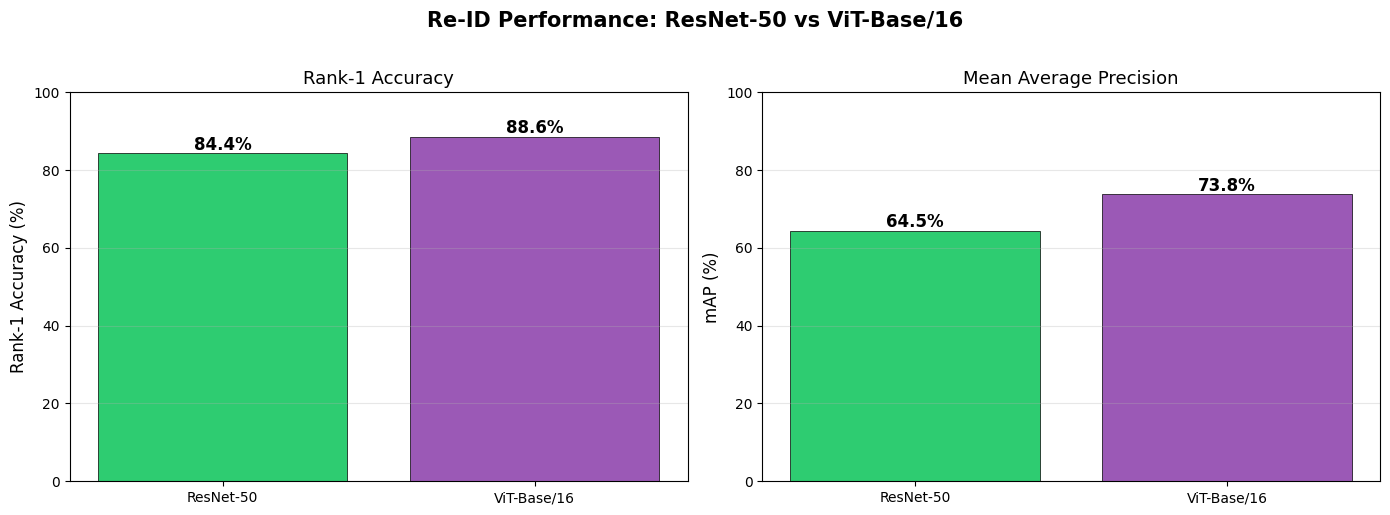

In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# Figure 2: Rank-1 & mAP bar chart comparison
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [ARCH_COLORS[n] for n in ARCH_NAMES]

# Rank-1
ax = axes[0]
r1_vals = [eval_results[n]['rank1'] * 100 for n in ARCH_NAMES]
bars = ax.bar(ARCH_NAMES, r1_vals, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, r1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Rank-1 Accuracy (%)', fontsize=12)
ax.set_title('Rank-1 Accuracy', fontsize=13)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# mAP
ax = axes[1]
map_vals = [eval_results[n]['mAP'] * 100 for n in ARCH_NAMES]
bars = ax.bar(ARCH_NAMES, map_vals, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, map_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('mAP (%)', fontsize=12)
ax.set_title('Mean Average Precision', fontsize=13)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Re-ID Performance: ResNet-50 vs ViT-Base/16', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/architecture_reid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. CMC Curves

The Cumulative Matching Characteristic (CMC) curve shows the probability
that the correct identity appears within the top-k ranked gallery images.

In [14]:
def compute_cmc(query_pids, gallery_pids, distmat,
                query_camids=None, gallery_camids=None, max_rank=50):
    """
    Computes the CMC curve up to max_rank.

    Returns:
        cmc (np.ndarray): CMC curve of shape (max_rank,)
    """
    m, n = distmat.shape
    indices = np.argsort(distmat, axis=1)
    all_cmc = []

    for i in range(m):
        q_pid = query_pids[i]
        order = indices[i]

        if query_camids is not None and gallery_camids is not None:
            q_camid = query_camids[i]
            remove = (gallery_pids[order] == q_pid) & (gallery_camids[order] == q_camid)
            keep = ~remove
        else:
            keep = np.ones(n, dtype=bool)

        matches = (gallery_pids[order[keep]] == q_pid).astype(np.int32)
        if matches.sum() == 0:
            continue

        cmc = matches.cumsum()
        cmc[cmc > 1] = 1
        all_cmc.append(cmc[:max_rank])

    return np.array(all_cmc, dtype=np.float32).mean(axis=0)

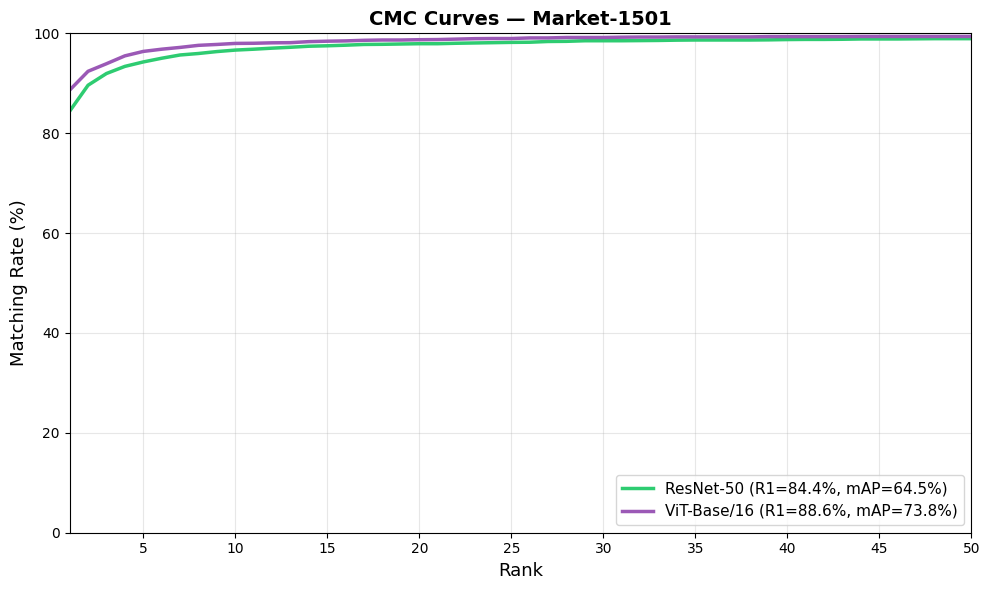

In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# Figure 3: CMC curves side by side
# ──────────────────────────────────────────────────────────────────────────────

MAX_RANK = 50

fig, ax = plt.subplots(figsize=(10, 6))

for name in ARCH_NAMES:
    r = eval_results[name]
    cmc = compute_cmc(r['q_pids'], r['g_pids'], r['distmat'],
                      r['q_cams'], r['g_cams'], max_rank=MAX_RANK)
    ax.plot(range(1, MAX_RANK + 1), cmc * 100,
            color=ARCH_COLORS[name], linewidth=2.5,
            label=f"{name} (R1={r['rank1']*100:.1f}%, mAP={r['mAP']*100:.1f}%)")

ax.set_xlabel('Rank', fontsize=13)
ax.set_ylabel('Matching Rate (%)', fontsize=13)
ax.set_title('CMC Curves — Market-1501', fontsize=14, fontweight='bold')
ax.set_xlim(1, MAX_RANK)
ax.set_ylim(0, 100)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('results/architecture_cmc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Qualitative Retrieval Comparison

For the same query images, compare retrieval results from both models.

In [16]:
from PIL import Image
import random

def compare_retrievals(query_ds_r, gallery_ds_r, distmat_r,
                       query_ds_v, gallery_ds_v, distmat_v,
                       query_index=None, top_k=5):
    """
    Side-by-side retrieval comparison for a single query.
    Top row: ResNet-50 results.  Bottom row: ViT-Base/16 results.
    """
    if query_index is None:
        query_index = random.randint(0, min(len(query_ds_r), len(query_ds_v)) - 1)
    
    fig, axes = plt.subplots(2, top_k + 1, figsize=(3 * (top_k + 1), 7))

    for row, (label, q_ds, g_ds, dm) in enumerate([
        ('ResNet-50',   query_ds_r, gallery_ds_r, distmat_r),
        ('ViT-Base/16', query_ds_v, gallery_ds_v, distmat_v),
    ]):
        q_pid = q_ds.pids[query_index]
        q_img = Image.open(q_ds.files[query_index]).convert('RGB')
        sorted_idx = np.argsort(dm[query_index])

        axes[row][0].imshow(q_img)
        axes[row][0].set_title(f'{label}\nQUERY ID:{q_pid}', fontweight='bold', fontsize=9)
        axes[row][0].axis('off')

        for k in range(top_k):
            g_idx = sorted_idx[k]
            g_pid = g_ds.pids[g_idx]
            g_img = Image.open(g_ds.files[g_idx]).convert('RGB')
            axes[row][k + 1].imshow(g_img)
            color = 'green' if g_pid == q_pid else 'red'
            axes[row][k + 1].set_title(f'Rank {k+1}\nID:{g_pid}', color=color, fontsize=9)
            axes[row][k + 1].axis('off')

    plt.tight_layout()
    plt.show()

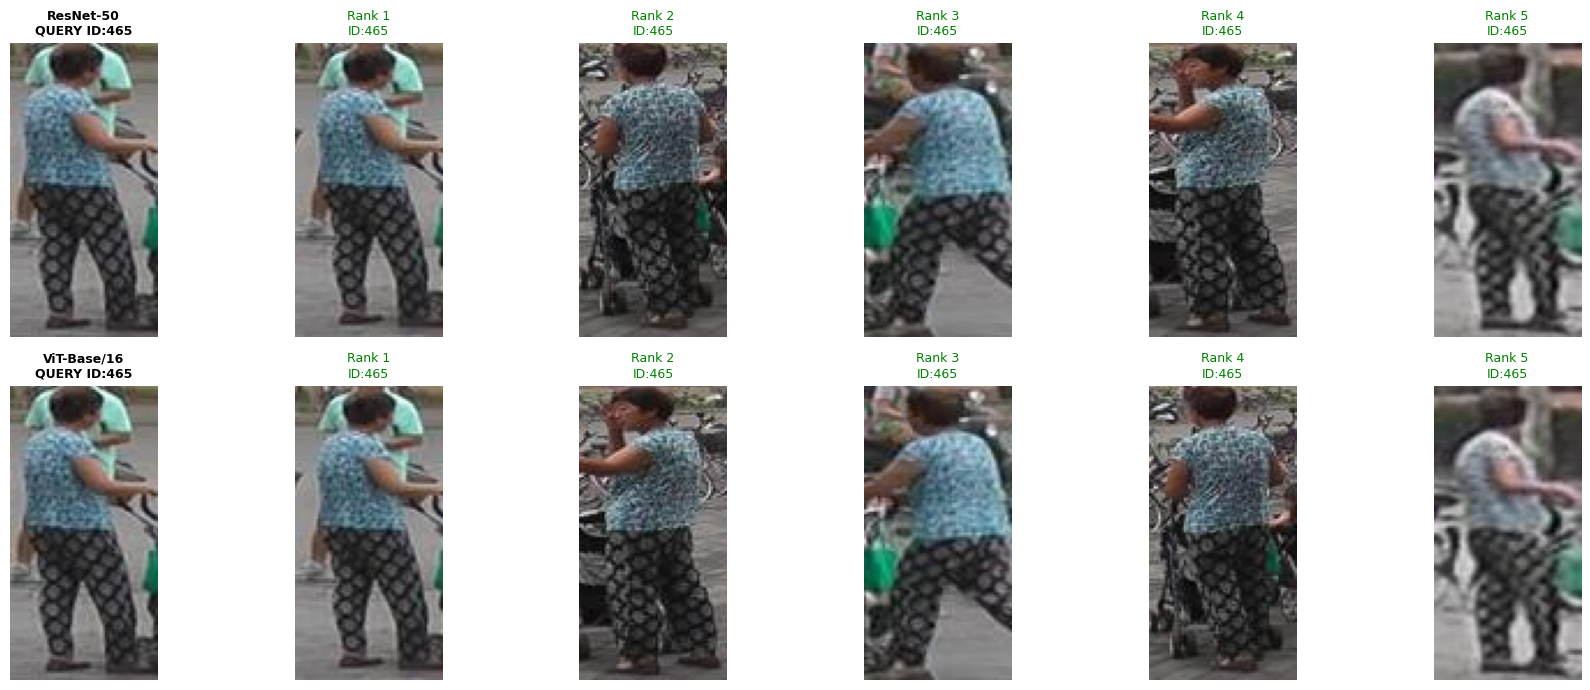

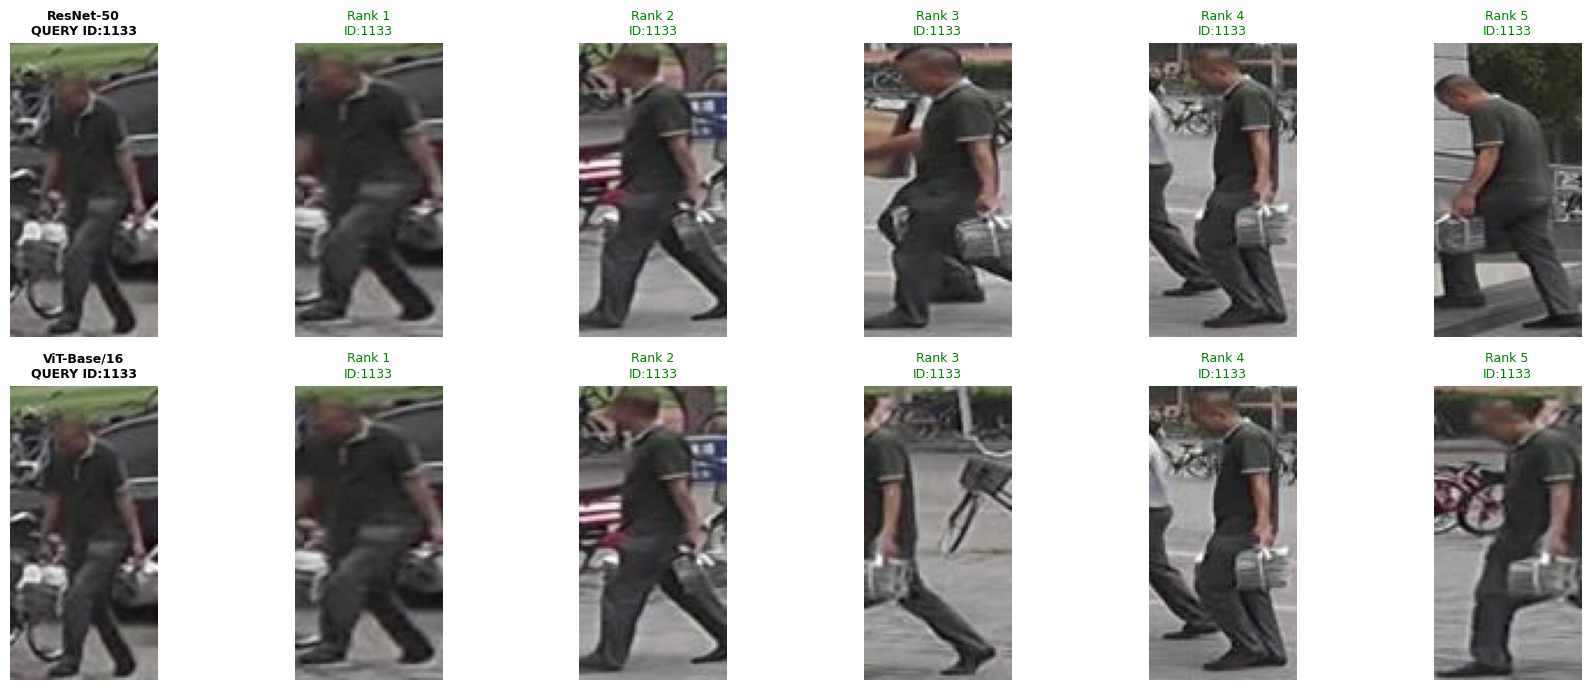

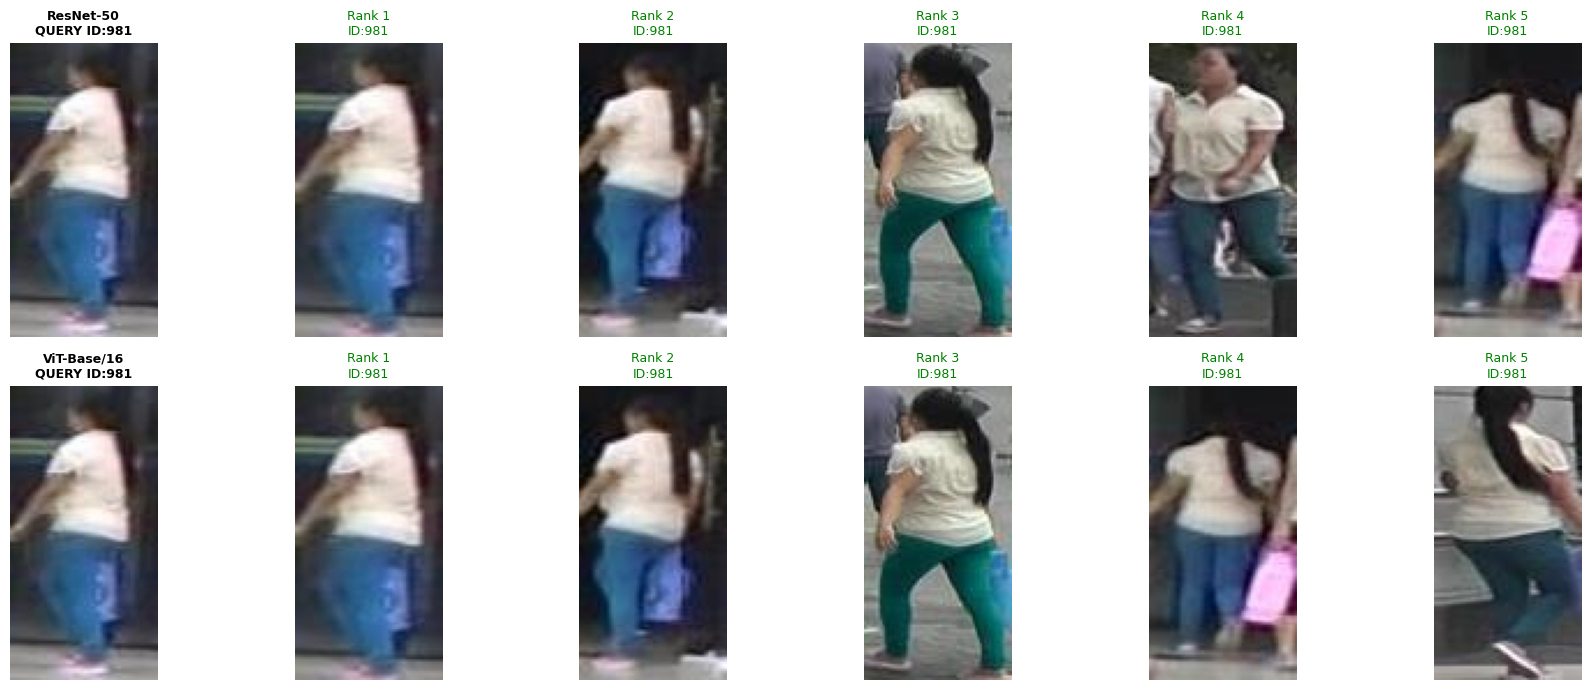

In [17]:
# Show 3 random query comparisons
for _ in range(3):
    compare_retrievals(
        q_ds_r, g_ds_r, distmat_r,
        q_ds_v, g_ds_v, distmat_v,
        top_k=5
    )

## 5. Embedding Space Visualisation (t-SNE)

t-SNE projects the high-dimensional embeddings (2048-d / 768-d) to 2D for visualisation.
Well-separated clusters indicate strong identity discrimination.

In [18]:
from sklearn.manifold import TSNE

def plot_tsne(features, pids, title, ax, n_samples=2000, n_identities=10, seed=42):
    """
    t-SNE visualisation of embeddings, coloured by identity.
    Subsamples for speed and readability.
    """
    np.random.seed(seed)

    # Select a subset of identities for clarity
    unique_pids = np.unique(pids)
    selected_pids = np.random.choice(unique_pids, size=min(n_identities, len(unique_pids)), replace=False)
    mask = np.isin(pids, selected_pids)

    feat_sub = features[mask][:n_samples]
    pids_sub = pids[mask][:n_samples]

    if torch.is_tensor(feat_sub):
        feat_sub = feat_sub.numpy()

    tsne = TSNE(n_components=2, perplexity=30, random_state=seed, n_iter=1000)
    emb_2d = tsne.fit_transform(feat_sub)

    # Assign a colour to each identity
    pid_to_idx = {pid: i for i, pid in enumerate(sorted(set(pids_sub)))}
    colors = [pid_to_idx[p] for p in pids_sub]

    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors,
                         cmap='tab10', s=15, alpha=0.7)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

    return scatter

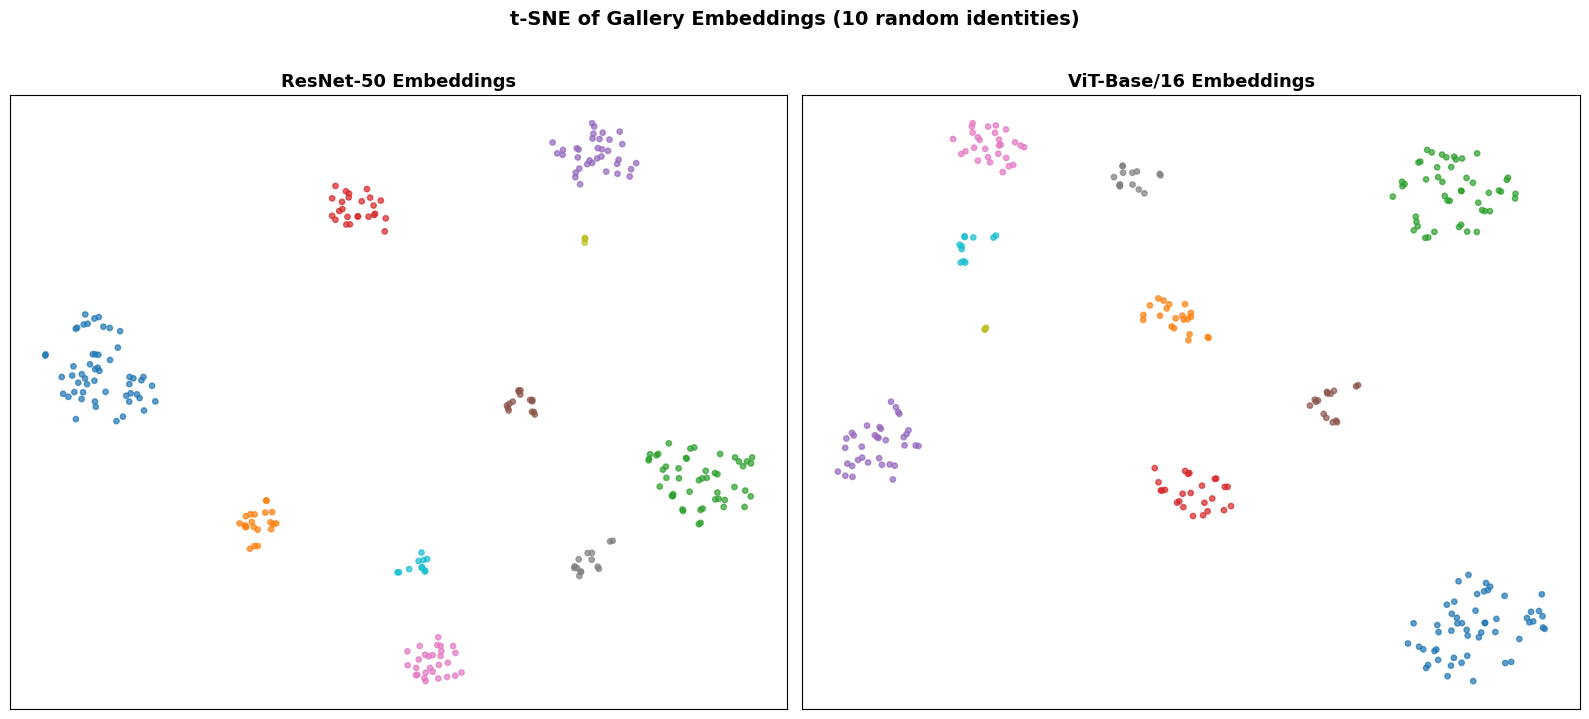

In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# Figure 4: t-SNE embedding comparison
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

r = eval_results['ResNet-50']
plot_tsne(r['g_feat'], r['g_pids'], 'ResNet-50 Embeddings', axes[0])

v = eval_results['ViT-Base/16']
plot_tsne(v['g_feat'], v['g_pids'], 'ViT-Base/16 Embeddings', axes[1])

plt.suptitle('t-SNE of Gallery Embeddings (10 random identities)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/architecture_tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comprehensive Summary Table

In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# Final summary table — all metrics in one place
# ──────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("  ARCHITECTURE COMPARISON — COMPREHENSIVE SUMMARY")
print("="*80)
print(f"\n{'Metric':<30} {'ResNet-50':>20} {'ViT-Base/16':>20}")
print('─' * 72)

r_cost, v_cost = cost_metrics['ResNet-50'], cost_metrics['ViT-Base/16']
r_eval, v_eval = eval_results['ResNet-50'], eval_results['ViT-Base/16']

rows = [
    # Architecture
    ('Architecture',         'CNN (Convolutional)',  'Transformer (Attn)'),
    ('Backbone',             'ResNet-50',            'ViT-Base/16'),
    ('Input Resolution',     str(RESNET_SIZE),       str(VIT_SIZE)),
    ('Feature Dimension',    '2048',                 '768'),
    ('', '', ''),
    # Cost
    ('Total Parameters',     f"{r_cost['total_params']/1e6:.1f}M",
                             f"{v_cost['total_params']/1e6:.1f}M"),
    ('FLOPs',                f"{r_cost['flops']/1e9:.2f} GFLOPs",
                             f"{v_cost['flops']/1e9:.2f} GFLOPs"),
    ('Latency (ms/image)',   f"{r_cost['latency_mean']:.1f} ± {r_cost['latency_std']:.1f}",
                             f"{v_cost['latency_mean']:.1f} ± {v_cost['latency_std']:.1f}"),
    ('', '', ''),
    # Performance
    ('Rank-1 (%)',           f"{r_eval['rank1']*100:.2f}",
                             f"{v_eval['rank1']*100:.2f}"),
    ('mAP (%)',              f"{r_eval['mAP']*100:.2f}",
                             f"{v_eval['mAP']*100:.2f}"),
]

for metric, rv, vv in rows:
    if metric == '':
        print()
    else:
        print(f"{metric:<30} {rv:>20} {vv:>20}")

# Highlight winners
print("\n" + "─"*72)
r1_winner = 'ResNet-50' if r_eval['rank1'] >= v_eval['rank1'] else 'ViT-Base/16'
map_winner = 'ResNet-50' if r_eval['mAP'] >= v_eval['mAP'] else 'ViT-Base/16'
speed_winner = 'ResNet-50' if r_cost['latency_mean'] <= v_cost['latency_mean'] else 'ViT-Base/16'

print(f"Best Rank-1  : {r1_winner}")
print(f"Best mAP     : {map_winner}")
print(f"Fastest      : {speed_winner}")


  ARCHITECTURE COMPARISON — COMPREHENSIVE SUMMARY

Metric                                    ResNet-50          ViT-Base/16
────────────────────────────────────────────────────────────────────────
Architecture                    CNN (Convolutional)   Transformer (Attn)
Backbone                                  ResNet-50          ViT-Base/16
Input Resolution                         (256, 128)           (224, 224)
Feature Dimension                              2048                  768

Total Parameters                              25.1M                86.4M
FLOPs                                   4.05 GFLOPs          6.46 GFLOPs
Latency (ms/image)                       13.0 ± 0.6           10.7 ± 0.6

Rank-1 (%)                                    84.41                88.63
mAP (%)                                       64.47                73.84

────────────────────────────────────────────────────────────────────────
Best Rank-1  : ViT-Base/16
Best mAP     : ViT-Base/16
Fastest      : 

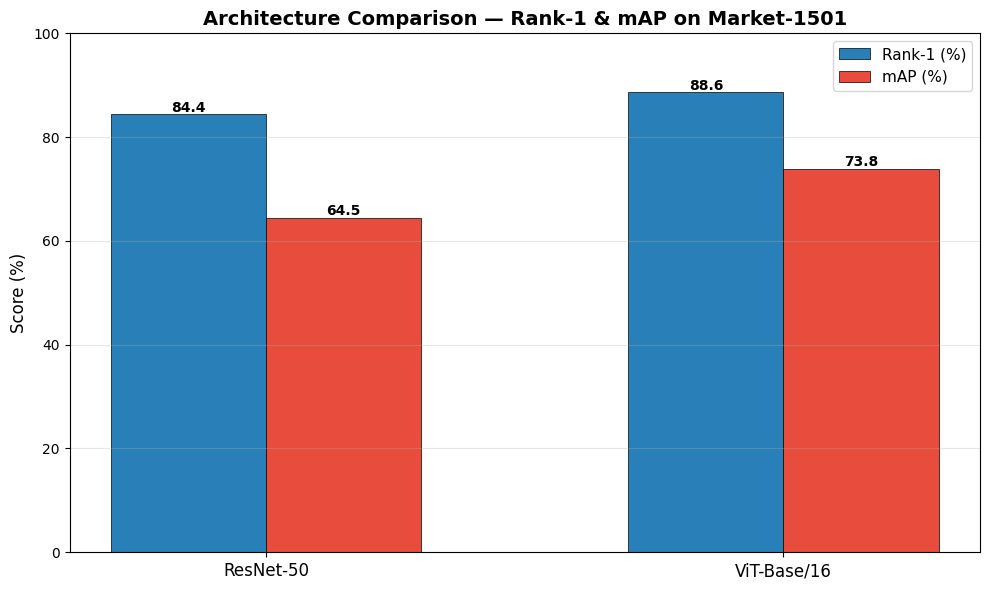

All figures saved to results/


In [21]:
# ──────────────────────────────────────────────────────────────────────────────
# Figure 5: Combined overview — grouped bar chart (Rank-1 + mAP)
# ──────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(ARCH_NAMES))
width = 0.30

r1_vals  = [eval_results[n]['rank1'] * 100 for n in ARCH_NAMES]
map_vals = [eval_results[n]['mAP'] * 100 for n in ARCH_NAMES]

bars1 = ax.bar(x - width / 2, r1_vals, width, label='Rank-1 (%)',
               color='#2980b9', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width / 2, map_vals, width, label='mAP (%)',
               color='#e74c3c', edgecolor='black', linewidth=0.5)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(ARCH_NAMES, fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Architecture Comparison — Rank-1 & mAP on Market-1501',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/architecture_grouped_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("All figures saved to results/")

## 7. Analysis & Conclusions

### Architectural Differences

**ResNet-50 (CNN):**
- Strong *inductive biases*: local receptive fields, translation equivariance, weight sharing
- Builds features hierarchically: edges → textures → parts → objects
- Efficient for smaller images due to progressive downsampling
- The `last_stride=1` trick preserves spatial resolution, critical for Re-ID

**ViT-Base/16 (Transformer):**
- *Global attention* from the first layer — can model long-range dependencies immediately
- No built-in locality bias — must learn spatial relationships from data
- [CLS] token aggregates information from all patches equally
- Higher parameter count but compact feature dimension (768 vs 2048)

### Practical Recommendations

| Scenario | Recommended Architecture |
|---|---|
| Resource-constrained deployment | ResNet-50 (faster, smaller) |
| Maximum accuracy, ample compute | ViT (with more training data/epochs) |
| Small dataset with limited labels | ResNet-50 (stronger inductive bias) |
| Multi-camera with large viewpoint changes | ViT (global attention captures pose) |

### Future Directions

- **Hybrid architectures**: Combine CNN local features with Transformer global attention (e.g., TransReID)
- **Longer training**: ViTs typically need more epochs to converge fully
- **Part-based attention**: Leverage ViT's patch tokens for body-part alignment
- **DeiT-style distillation**: Use CNN as teacher, ViT as student for efficient training